In [1]:
import csv
f = open("portfolio.csv")
csvfile = csv.DictReader(f, delimiter='\t')

headers = csvfile.fieldnames

table = []
for row in csvfile:
    table.append(row)
    
f.close()

In [2]:
print(headers)

['Stock', 'IBM', 'XOM', 'GE', 'MSFT', 'C', 'BAC', 'BP', 'PG', 'PFE', 'JNJ']


In [3]:
Stocks = headers[:]
Stocks.remove('Stock')

In [4]:
print(Stocks)

['IBM', 'XOM', 'GE', 'MSFT', 'C', 'BAC', 'BP', 'PG', 'PFE', 'JNJ']


In [16]:
for row in table:
    print(row)

{'Stock': 'IBM', 'IBM': '6.767369629', 'XOM': '-2.520731956', 'GE': '1.269446364', 'MSFT': '3.179452307', 'C': '-0.41034375', 'BAC': '-3.133160297', 'BP': '0.913850139', 'PG': '1.10916305', 'PFE': '0.963070936', 'JNJ': '-2.159744382'}
{'Stock': 'XOM', 'IBM': '-2.520731956', 'XOM': '6.86176769', 'GE': '-0.530105679', 'MSFT': '-0.85614784', 'C': '1.071717434', 'BAC': '4.221718088', 'BP': '4.867420429', 'PG': '0.037386466', 'PFE': '0.625382804', 'JNJ': '1.295764604'}
{'Stock': 'GE', 'IBM': '1.269446364', 'XOM': '-0.530105679', 'GE': '0.585169945', 'MSFT': '-0.027693144', 'C': '0.601940132', 'BAC': '0.204006787', 'BP': '0.477021364', 'PG': '-0.487989162', 'PFE': '-0.11194169', 'JNJ': '0.133372057'}
{'Stock': 'MSFT', 'IBM': '3.179452307', 'XOM': '-0.85614784', 'GE': '-0.027693144', 'MSFT': '3.886260868', 'C': '-1.976308882', 'BAC': '-3.467663128', 'BP': '-0.951767348', 'PG': '2.766403623', 'PFE': '1.185039781', 'JNJ': '-1.75198183'}
{'Stock': 'C', 'IBM': '-0.41034375', 'XOM': '1.071717434',

In [5]:
# create a dictionary for covariance and return parameters
Covariance = {}
Return = {}
for row in table:
    if row['Stock'] != 'Proj. Return':
        for i in Stocks:
            Covariance[row['Stock'], i] = float(row[i])
    else:
        for i in Stocks:
            Return[i] = float(row[i])

In [9]:
Covariance

{('IBM', 'IBM'): 6.767369629,
 ('IBM', 'XOM'): -2.520731956,
 ('IBM', 'GE'): 1.269446364,
 ('IBM', 'MSFT'): 3.179452307,
 ('IBM', 'C'): -0.41034375,
 ('IBM', 'BAC'): -3.133160297,
 ('IBM', 'BP'): 0.913850139,
 ('IBM', 'PG'): 1.10916305,
 ('IBM', 'PFE'): 0.963070936,
 ('IBM', 'JNJ'): -2.159744382,
 ('XOM', 'IBM'): -2.520731956,
 ('XOM', 'XOM'): 6.86176769,
 ('XOM', 'GE'): -0.530105679,
 ('XOM', 'MSFT'): -0.85614784,
 ('XOM', 'C'): 1.071717434,
 ('XOM', 'BAC'): 4.221718088,
 ('XOM', 'BP'): 4.867420429,
 ('XOM', 'PG'): 0.037386466,
 ('XOM', 'PFE'): 0.625382804,
 ('XOM', 'JNJ'): 1.295764604,
 ('GE', 'IBM'): 1.269446364,
 ('GE', 'XOM'): -0.530105679,
 ('GE', 'GE'): 0.585169945,
 ('GE', 'MSFT'): -0.027693144,
 ('GE', 'C'): 0.601940132,
 ('GE', 'BAC'): 0.204006787,
 ('GE', 'BP'): 0.477021364,
 ('GE', 'PG'): -0.487989162,
 ('GE', 'PFE'): -0.11194169,
 ('GE', 'JNJ'): 0.133372057,
 ('MSFT', 'IBM'): 3.179452307,
 ('MSFT', 'XOM'): -0.85614784,
 ('MSFT', 'GE'): -0.027693144,
 ('MSFT', 'MSFT'): 3.88

In [10]:
Return

{'IBM': 0.08,
 'XOM': 0.09,
 'GE': 0.03,
 'MSFT': 0.04,
 'C': 0.045,
 'BAC': 0.045,
 'BP': 0.052,
 'PG': 0.062,
 'PFE': 0.08,
 'JNJ': 0.053}

In [17]:
from docplex.mp.model import Model
mdl = Model()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [18]:
# variables
proportion = mdl.continuous_var_dict(Stocks, lb=0, ub=1, name='proportion')

In [19]:
# objective
TotalVariance = mdl.sum(Covariance[i,j]*proportion[i]*proportion[j] for (i,j) in Covariance.keys())
mdl.minimize(TotalVariance)

In [20]:
# constraints: proportions add up to 1
mdl.add_constraint(mdl.sum(proportion[i] for i in Stocks) == 1)

docplex.mp.LinearConstraint[](proportion_IBM+proportion_XOM+proportion_GE+proportion_MSFT+proportion_C+proportion_BAC+proportion_BP+proportion_PG+proportion_PFE+proportion_JNJ,EQ,1)

In [21]:
# constraint: minimum return
mdl.add_constraint(mdl.sum(Return[i]*proportion[i] for i in Stocks) >= 0.08, "return")

docplex.mp.LinearConstraint[return](0.080proportion_IBM+0.090proportion_XOM+0.030proportion_GE+0.040proportion_MSFT+0.045proportion_C+0.045proportion_BAC+0.052proportion_BP+0.062proportion_PG+0.080proportion_PFE+0.053proportion_JNJ,GE,0.080)

In [22]:
# solve
mdl.solve()
mdl.get_solve_details()

docplex.mp.SolveDetails(time=0.015,status='optimal')

In [25]:
mdl.print_solution()

objective: 0.426
  proportion_IBM=0.048
  proportion_XOM=0.000
  proportion_GE=0.000
  proportion_MSFT=0.000
  proportion_C=0.165
  proportion_BAC=0.000
  proportion_BP=0.000
  proportion_PG=0.000
  proportion_PFE=0.630
  proportion_JNJ=0.157


In [27]:
# create an efficient frontier
FrontierX = []
FrontierY = []

for r in range(10,90):
    mdl.get_constraint_by_name("return").rhs = r/1000
    mdl.solve()
    FrontierX.append(r/1000)
    FrontierY.append(TotalVariance.solution_value)

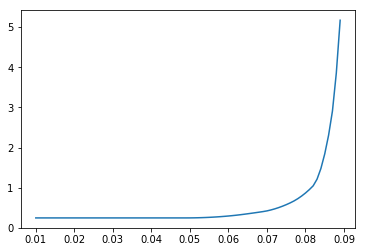

In [33]:
import matplotlib.pyplot as plt
plt.plot(FrontierX, FrontierY)